# Tree-Based Models & Ensembles — Assignment Notebook
### Week 5 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right tool, parameter, or formula and justify why.

---


In [1]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, f1_score,
                             recall_score, precision_score, roc_curve)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_moons
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap, joblib

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [11, 5]

# Load the Telco dataset (used from Section 2 onwards)
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
print(f"Dataset loaded: {df_raw.shape}"); print(df_raw.dtypes.tail(6))


Dataset loaded: (7043, 21)
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


---
## Section 1: Decision Tree Building Blocks

Before using sklearn, prove you understand what a tree *actually does* by implementing the core math yourself.

---

### Q1 — Implement Gini Impurity from Scratch

A Decision Tree evaluates every candidate split by measuring how *impure* the resulting child nodes are. Gini is the most common measure.

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

where $p_k$ is the fraction of samples belonging to class $k$ at node $t$.

**Your task:** Complete the function below. Do not use any sklearn or numpy impurity functions — implement the formula directly.


In [3]:
def gini_impurity(class_counts):
    """
    Compute Gini impurity for a single node.

    Parameters
    ----------
    class_counts : list or array of ints
        Number of samples per class at this node.
        e.g. [70, 30] means 70 samples of class-0, 30 of class-1

    Returns
    -------
    float : Gini value in [0, 0.5] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0

    # YOUR CODE HERE
    gini = 1 - sum((count / total) ** 2 for count in class_counts)
    return gini


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(gini_impurity([100, 0])   - 0.000) < 1e-6, "Pure node should have Gini = 0"
assert abs(gini_impurity([50,  50])  - 0.500) < 1e-6, "Equal split should have Gini = 0.5"
assert abs(gini_impurity([70,  30])  - 0.420) < 1e-6, "70/30 split should have Gini = 0.42"
assert abs(gini_impurity([10,  10, 10]) - round(1 - 3*(1/3)**2, 6)) < 1e-5, "3-class test failed"
print("✅ All gini_impurity checks passed!")


✅ All gini_impurity checks passed!


### Q2 — Implement Shannon Entropy

Entropy is the alternative impurity measure. It measures *information* rather than probability of mislabelling.

$$H(t) = -\sum_{k} p_k \log_2(p_k)$$

**Convention:** $0 \cdot \log_2(0) = 0$ (a class with zero samples contributes nothing).


In [4]:
def entropy(class_counts):
    """
    Compute Shannon entropy for a single node.

    Returns
    -------
    float : entropy in [0, 1] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0

    # YOUR CODE HERE
    # Hint: use math.log2 or np.log2; skip terms where p_k == 0
    h = -sum((count / total) * np.log2(count / total) for count in class_counts if count > 0)
    return h


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(entropy([100, 0])  - 0.000) < 1e-6, "Pure node should have H = 0"
assert abs(entropy([50,  50]) - 1.000) < 1e-6, "Equal binary split should have H = 1"
assert abs(entropy([70,  30]) - (-0.7*np.log2(0.7) - 0.3*np.log2(0.3))) < 1e-5
print("✅ All entropy checks passed!")

✅ All entropy checks passed!


### Q3 — Compute Information Gain for a Candidate Split

A tree picks the split that maximises **Information Gain**:

$$\text{IG} = H(\text{parent}) - \sum_{c} \frac{n_c}{n} H(\text{child}_c)$$

**Scenario:** At a node with 1,000 samples (730 non-churners, 270 churners), you are evaluating a split on `Contract_Type`:
- Left child: 600 samples, 510 non-churn / 90 churn
- Right child: 400 samples, 220 non-churn / 180 churn

**Your task:** Use your `entropy()` function to compute the information gain of this split.


In [5]:
# Use your entropy() function from Q2.
# Fill in the four variables below — do not hard-code the IG formula output.

parent_counts = [730, 270]      # [non-churn, churn] at the parent node
left_counts   = [510,  90]      # counts in the left child
right_counts  = [220, 180]      # counts in the right child

n_total = sum(parent_counts)
n_left  = sum(left_counts)
n_right = sum(right_counts)

# YOUR CODE HERE — compute information gain using your entropy() function
parent_entropy   = entropy(parent_counts)   # H of the parent node
weighted_entropy = (n_left / n_total) * entropy(left_counts) + (n_right / n_total) * entropy(right_counts)   # weighted average entropy of the two children
information_gain = parent_entropy - weighted_entropy   # IG = parent - weighted children

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert information_gain > 0, "Information gain should be positive for a useful split"
assert information_gain < parent_entropy, "IG cannot exceed parent entropy"
print(f"Parent Entropy:    {parent_entropy:.4f}")
print(f"Weighted Child H:  {weighted_entropy:.4f}")
print(f"Information Gain:  {information_gain:.4f}")
print("✅ Information gain computed correctly!")

Parent Entropy:    0.8415
Weighted Child H:  0.7630
Information Gain:  0.0785
✅ Information gain computed correctly!


✍️ **Reflect 1:** Look at the right child: 220 non-churn vs 180 churn.
It is still mixed, but it is more balanced than the parent, so the split reduced impurity.
A high information gain means the split created child nodes that are more informative and easier to classify.

---
## Section 2: Bias, Variance, and the Depth Problem

---

### Q4 — The Bias-Variance Curve

**Your task:** Train decision trees at depths 1 through 20 (plus `None` = unlimited) on the moons dataset. Record both training accuracy and test accuracy for each depth.

You must:
1. Fill in the `for` loop to train a tree and record both scores
2. Identify the depth with the highest test accuracy
3. Answer the reflection question


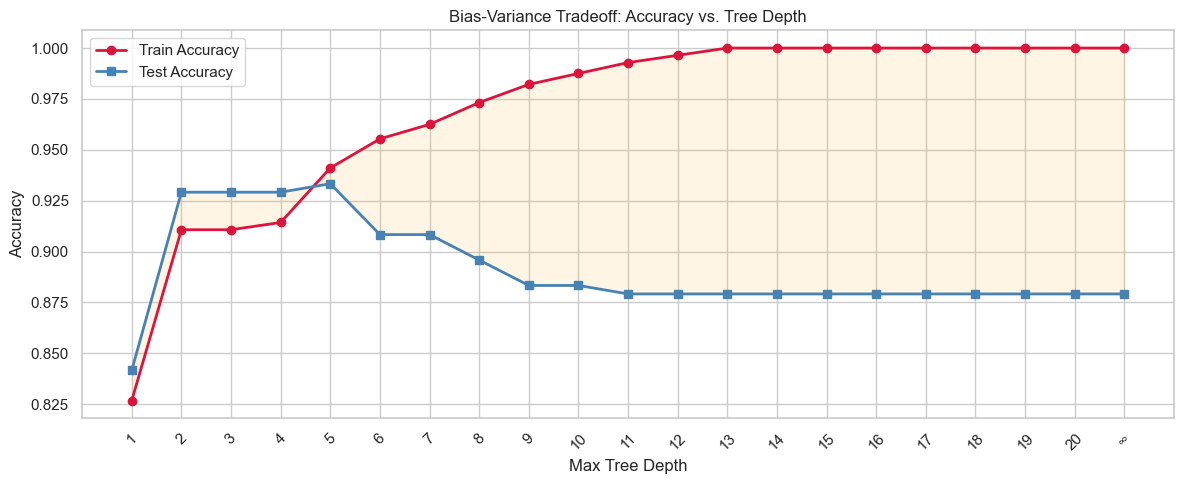

Best test accuracy at depth = 5: 0.9333
Train acc at depth=∞: 1.0000   Test acc at depth=∞: 0.8792
Variance gap at depth=∞: 0.1208


In [6]:
from sklearn.datasets import make_moons

X_bv, y_bv = make_moons(n_samples=800, noise=0.30, random_state=42)
X_tr_bv, X_te_bv, y_tr_bv, y_te_bv = train_test_split(
    X_bv, y_bv, test_size=0.30, random_state=42)

depths       = list(range(1, 21)) + [None]
train_scores = []
test_scores  = []

for d in depths:
    # YOUR CODE HERE
    # 1. Instantiate a DecisionTreeClassifier with max_depth=d and random_state=42
    # 2. Fit on (X_tr_bv, y_tr_bv)
    # 3. Append the training accuracy to train_scores
    # 4. Append the test accuracy to test_scores
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_tr_bv, y_tr_bv)
    train_scores.append(tree.score(X_tr_bv, y_tr_bv))
    test_scores.append(tree.score(X_te_bv, y_te_bv))

# Plotting (run as-is after filling the loop)
depth_labels = [str(d) if d else '∞' for d in depths]
plt.figure(figsize=(12, 5))
plt.plot(depth_labels, train_scores, 'o-', color='crimson', lw=2, label='Train Accuracy')
plt.plot(depth_labels, test_scores,  's-', color='steelblue', lw=2, label='Test Accuracy')
plt.fill_between(range(len(depths)), train_scores, test_scores, alpha=0.10, color='orange')
plt.xlabel('Max Tree Depth'); plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Accuracy vs. Tree Depth')
plt.legend(); plt.xticks(range(len(depths)), depth_labels, rotation=45)
plt.tight_layout(); plt.show()

best_depth_idx = int(np.argmax(test_scores))
print(f"Best test accuracy at depth = {depth_labels[best_depth_idx]}: {test_scores[best_depth_idx]:.4f}")
print(f"Train acc at depth=∞: {train_scores[-1]:.4f}   Test acc at depth=∞: {test_scores[-1]:.4f}")
print(f"Variance gap at depth=∞: {train_scores[-1] - test_scores[-1]:.4f}")

✍️ **Reflect 2:** The unlimited-depth tree achieves ~100% training accuracy.
This is overfitting, or high variance.
The large train-test gap means the model memorized the training set instead of learning a pattern that generalizes.
Reporting only training accuracy is misleading because it hides poor performance on unseen data.

---
## Section 3: Data Prep & The Accuracy Trap

---

### Q5 — Fix the Telco Dataset

The raw Telco CSV has a well-known data quality issue: `TotalCharges` contains whitespace strings where the value is missing, which forces pandas to read the entire column as `object` (string) instead of `float`.

**Your task:** Fix this in three steps — detect, coerce, and impute.


In [7]:
df = df_raw.copy()

# Step 1 — How many rows have a blank/whitespace TotalCharges?
# YOUR CODE HERE: print the count of rows where TotalCharges.str.strip() == ''
n_whitespace = df['TotalCharges'].astype(str).str.strip().eq('').sum()
print(f"Rows with whitespace TotalCharges: {n_whitespace}")

# Step 2 — Fix: coerce to numeric (errors → NaN), then impute with the median
# YOUR CODE HERE: convert df['TotalCharges'] to numeric, fill NaN with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Step 3 — Encode the target and drop the ID column
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df['TotalCharges'].dtype in [np.float64, np.float32, float],     f"TotalCharges should be float, got {df['TotalCharges'].dtype}"
assert df['TotalCharges'].isnull().sum() == 0, "No NaN should remain after imputation"
assert set(df['Churn'].unique()) == {0, 1}, "Churn should be binary int"
print(f"✅ Dataset clean. Shape: {df.shape}")
print(f"   Churn rate: {df['Churn'].mean()*100:.1f}%")

Rows with whitespace TotalCharges: 11
✅ Dataset clean. Shape: (7043, 20)
   Churn rate: 26.5%


### Q6 — The Naive Tree and The Trap

Train an **unconstrained** DecisionTreeClassifier on the Telco data (use simple label-encoding for speed — proper pipelines come later).

Then deliberately evaluate it using **only accuracy** first. Then expose the trap by looking at the full report.


In [8]:
# Quick label encoding for the naive baseline
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = df_enc[col].astype('category').cat.codes

X_naive = df_enc.drop('Churn', axis=1)
y_naive = df_enc['Churn']

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# YOUR CODE HERE
# 1. Train a DecisionTreeClassifier with NO constraints (no max_depth) and random_state=42
# 2. Compute y_pred_n on the test set
naive_tree = DecisionTreeClassifier(random_state=42)
naive_tree.fit(X_tr_n, y_tr_n)
y_pred_n   = naive_tree.predict(X_te_n)

# ── Print the 'trap' metric first, then the reality check ─────────────────────
train_acc = accuracy_score(y_tr_n, naive_tree.predict(X_tr_n))
test_acc  = accuracy_score(y_te_n, y_pred_n)

print("=" * 55)
print(f"  Plain Accuracy (The Trap): {test_acc:.4f}")
print("=" * 55)
print(f"  Tree Depth:    {naive_tree.get_depth()}")
print(f"  Train Acc:     {train_acc:.4f}")
print(f"  Test Acc:      {test_acc:.4f}")
print(f"  Variance Gap:  {train_acc - test_acc:.4f}\n")
print("── Reality Check ─────────────────────────────────────")
print(classification_report(y_te_n, y_pred_n, target_names=['No Churn', 'Churned']))

  Plain Accuracy (The Trap): 0.7303
  Tree Depth:    24
  Train Acc:     0.9980
  Test Acc:      0.7303
  Variance Gap:  0.2677

── Reality Check ─────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.82      0.81      0.81      1035
     Churned       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



✍️ **Reflect 3:** The accuracy looks acceptable (~73%).
Now look at the Recall for the **Churned** class.
- What percentage of actual churners did the model correctly flag?
- Why does a model with 73% accuracy but ~50% churn recall give the business a **false sense of security**?
- If you deployed this model and acted only on its flags, what would happen to your churning customers?

> *Your answer:*


✍️ **Reflect 3:** The accuracy looks acceptable (~73%).
That can still be a weak churn model because accuracy is dominated by the majority class.
A model with only ~50% churn recall misses many at-risk customers, so the business gets a false sense of security.
The key issue is that churn detection matters more than overall accuracy here.

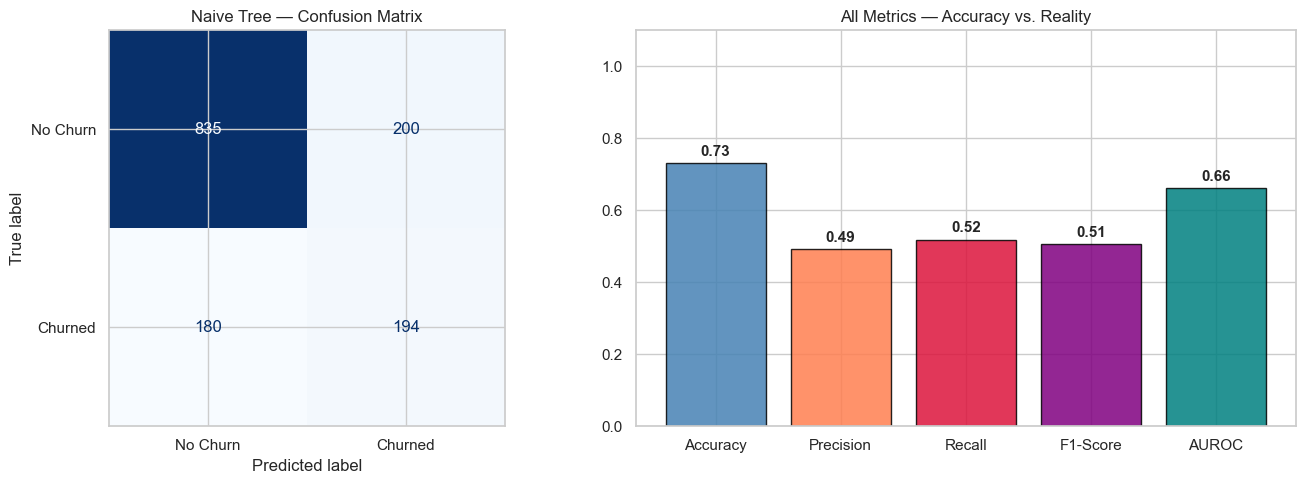

TP=194 | FP=200 | FN=180 | TN=835
Precision (manual): 0.4924
Recall    (manual): 0.5187
F1-Score  (manual): 0.5052


In [9]:
cm = confusion_matrix(y_te_n, y_pred_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Tree — Confusion Matrix', fontsize=12)

TN, FP, FN, TP = cm.ravel()

# YOUR CODE HERE — compute the four metrics from scratch using TN, FP, FN, TP
# Do NOT use sklearn metric functions here. Use the formulas directly.
precision_manual = TP / (TP + FP) if (TP + FP) else 0.0   # TP / (TP + FP)
recall_manual    = TP / (TP + FN) if (TP + FN) else 0.0   # TP / (TP + FN)
f1_manual        = (2 * precision_manual * recall_manual / (precision_manual + recall_manual)
                    if (precision_manual + recall_manual) else 0.0)   # 2 * precision * recall / (precision + recall)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(precision_manual - precision_score(y_te_n, y_pred_n)) < 1e-4
assert abs(recall_manual    - recall_score(y_te_n, y_pred_n))    < 1e-4
assert abs(f1_manual        - f1_score(y_te_n, y_pred_n))        < 1e-4

# Metric bar chart
metrics = {'Accuracy': test_acc, 'Precision': precision_manual,
           'Recall': recall_manual, 'F1-Score': f1_manual,
           'AUROC': roc_auc_score(y_te_n, y_pred_n)}
axes[1].bar(metrics.keys(), metrics.values(),
            color=['steelblue','coral','crimson','purple','teal'], edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.1); axes[1].set_title('All Metrics — Accuracy vs. Reality', fontsize=12)
for x, (k, v) in enumerate(metrics.items()):
    axes[1].text(x, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"TP={TP} | FP={FP} | FN={FN} | TN={TN}")
print(f"Precision (manual): {precision_manual:.4f}")
print(f"Recall    (manual): {recall_manual:.4f}")
print(f"F1-Score  (manual): {f1_manual:.4f}")

✍️ **Reflect 4:** In the context of a telecom retention campaign:
- **FN:** About `$500` of lifetime value is lost per missed churner.
- **FP:** A retention offer, discount, or agent time is wasted on a customer who would have stayed anyway.
- **Priority:** Minimizing FN is usually more important, because missing a real churner costs more than contacting a few extra non-churners.

---
## Section 4: Ensembles — Building the Crowd

---

### Q8 — Implement Bootstrap Sampling from Scratch

Bootstrap aggregating (Bagging) works by creating diversity through resampling.
Before using sklearn, implement the core operation yourself.

**Your task:** Write a function that:
1. Draws $N$ samples **with replacement** from a dataset of size $N$
2. Returns both the bootstrap sample AND the out-of-bag (OOB) indices


In [10]:
def bootstrap_sample(X, y, random_state=None):
    """
    Draw one bootstrap sample from (X, y).

    Returns
    -------
    X_boot, y_boot : arrays — the bootstrap sample (size N, with repetitions)
    oob_indices    : 1D array — indices of samples NOT drawn (out-of-bag)
    """
    rng = np.random.RandomState(random_state)
    N   = len(X)

    # YOUR CODE HERE
    # 1. Draw N indices with replacement using rng.choice(N, size=N, replace=True)
    # 2. Use those indices to index into X and y
    # 3. Compute OOB indices: original indices that do NOT appear in your drawn indices
    bootstrap_indices = rng.choice(N, size=N, replace=True)
    X_boot = X[bootstrap_indices]
    y_boot = y[bootstrap_indices]
    oob_indices = np.setdiff1d(np.arange(N), np.unique(bootstrap_indices))
    return X_boot, y_boot, oob_indices


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
np.random.seed(0)
X_test_bs = np.arange(20).reshape(10, 2)
y_test_bs = np.arange(10)

Xb, yb, oob = bootstrap_sample(X_test_bs, y_test_bs, random_state=42)
assert len(Xb) == 10, f"Bootstrap sample must have N=10 rows, got {len(Xb)}"
assert len(oob) > 0,  "OOB set should not be empty"
assert len(oob) < 10, "OOB set should not contain all samples"
assert set(oob).isdisjoint(set(yb.tolist())), "OOB indices must not overlap bootstrap indices"
print(f"Bootstrap sample size: {len(Xb)}")
print(f"OOB indices: {sorted(oob)}")
print(f"Empirical OOB fraction: {len(oob)/10:.2f}  (theory predicts ~0.37)")
print("✅ bootstrap_sample() is correct!")

Bootstrap sample size: 10
OOB indices: [np.int64(0), np.int64(1), np.int64(5), np.int64(8)]
Empirical OOB fraction: 0.40  (theory predicts ~0.37)
✅ bootstrap_sample() is correct!


### Q9 — Random Forest: What's Different from Bagging?

Both Bagging and Random Forest use bootstrap sampling. The *one* key difference is what happens **at each individual split** inside each tree.

**Your task:**
1. Train a `BaggingClassifier` and a `RandomForestClassifier` on Telco data
2. Compare their AUROC scores
3. Answer the reflection question


In [11]:
# Use the label-encoded dataset from Section 3
X_tr, X_te, y_tr, y_te = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# YOUR CODE HERE
# Train a BaggingClassifier: 100 trees, bootstrap=True, oob_score=True, random_state=42, n_jobs=-1
# Train a RandomForestClassifier: 100 trees, random_state=42, n_jobs=-1
# Predict probabilities for both on X_te
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
rf_clf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
bag_clf.fit(X_tr, y_tr)
rf_clf.fit(X_tr, y_tr)

bag_auc = roc_auc_score(y_te, bag_clf.predict_proba(X_te)[:, 1])
rf_auc  = roc_auc_score(y_te, rf_clf.predict_proba(X_te)[:, 1])

print(f"Bagging AUROC:       {bag_auc:.4f}  (OOB score: {bag_clf.oob_score_:.4f})")
print(f"Random Forest AUROC: {rf_auc:.4f}")
print(f"Improvement from RF: {(rf_auc - bag_auc)*100:+.2f} pp")

Bagging AUROC:       0.8081  (OOB score: 0.7838)
Random Forest AUROC: 0.8225
Improvement from RF: +1.44 pp


✍️ **Reflect 5:** Both use bootstrap sampling, but Random Forest also randomly subsamples features at each split.
That decorrelates the trees, reduces variance, and usually improves generalization.
For classification, the default `max_features` is `sqrt(n_features)`, meaning each split considers about `sqrt(p)` features.

---
## Section 5: Boosting — Sequential Error Correction

---

### Q10 — XGBoost Regularisation Parameters

Gradient Boosting without constraints will overfit. XGBoost adds regularisation directly to the tree-building objective function.

**Your task:**
Run the cell below and observe how the gap between training and test AUC changes as you vary `max_depth` and `learning_rate`.

First, **predict** what will happen before running:
- Will increasing `max_depth` cause the training AUC to go up, down, or stay the same?
- Will it cause the test AUC to go up, down, or both?

Then fill in the param sweep.


In [12]:
# YOUR CODE HERE — fill the param_configs list with 4 XGBoost configurations:
# Each entry: dict with keys 'max_depth', 'learning_rate', 'n_estimators'
# Choose configs that let you explore the effect of depth and learning rate.
# Example structure (replace these with your own thoughtful choices):
#   {'max_depth': 2,  'learning_rate': 0.3, 'n_estimators': 100}
#   {'max_depth': 8,  'learning_rate': 0.3, 'n_estimators': 100}
#   {'max_depth': 3,  'learning_rate': 0.01,'n_estimators': 100}
#   {'max_depth': 3,  'learning_rate': 0.1, 'n_estimators': 200}

param_configs = [
    {'max_depth': 2, 'learning_rate': 0.30, 'n_estimators': 100},
    {'max_depth': 8, 'learning_rate': 0.30, 'n_estimators': 100},
    {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 300},
    {'max_depth': 3, 'learning_rate': 0.10, 'n_estimators': 200},
]

print(f"{'Config':<45} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 75)
results_xgb = []

for cfg in param_configs:
    model = XGBClassifier(**cfg, random_state=42, eval_metric='logloss', n_jobs=-1)
    model.fit(X_tr, y_tr)
    tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    te_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    label  = str(cfg)
    print(f"{label:<45} {tr_auc:>10.4f} {te_auc:>10.4f} {tr_auc-te_auc:>8.4f}")
    results_xgb.append({'config': label, 'train_auc': tr_auc, 'test_auc': te_auc})

Config                                         Train AUC   Test AUC      Gap
---------------------------------------------------------------------------
{'max_depth': 2, 'learning_rate': 0.3, 'n_estimators': 100}     0.8743     0.8424   0.0319
{'max_depth': 8, 'learning_rate': 0.3, 'n_estimators': 100}     0.9986     0.8134   0.1852
{'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 300}     0.8584     0.8427   0.0157
{'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200}     0.8884     0.8428   0.0455


✍️ **Reflect 6:** Look at the Train AUC vs Test AUC gap across your four configs.
- Which configuration showed the **most overfitting** (largest gap)? What parameter(s) caused it?
- Which configuration had the **best test AUC** overall?
- What would happen to the test AUC if you set `max_depth=1`? Is that always bad?

> *Your answer:*


### Q11 — Grid Search: Designing the Search Space

Grid Search is only as good as the grid you define. Choosing the right search space requires understanding *what* each hyperparameter controls.

**Your task:**
1. Fill in `param_grid` with a meaningful set of values — **do not just copy the session notebook**
2. Justify each range in the comment
3. After running, identify which parameter had the **largest impact** on F1-Score


In [13]:
# YOUR CODE HERE — define a param grid for XGBClassifier
# Think about:
#   max_depth:     what range avoids both underfitting and overfitting?
#   learning_rate: what's a reasonable range? (hint: too high = unstable, too low = slow)
#   n_estimators:  how many rounds? should this go with learning_rate?
param_grid = {
    'max_depth':     [2, 3, 5],   # modest depths to balance bias and variance
    'learning_rate': [0.01, 0.05, 0.1],   # low to moderate step sizes for stable boosting
    'n_estimators':  [100, 200, 300],   # more rounds for smaller learning rates
}
# Justification for my choices:
# max_depth:     shallow-to-moderate trees to avoid overfitting while still capturing interactions
# learning_rate: a span from very small to moderate values to show the shrinkage trade-off
# n_estimators:  enough boosting rounds to compensate for lower learning rates without exploding runtime

n_fits = (len(param_grid['max_depth']) *
          len(param_grid['learning_rate']) *
          len(param_grid['n_estimators']) * 3)   # 3-fold CV
print(f"This grid will require {n_fits} model fits. Estimated time: ~{n_fits*2}s")

gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=0, return_train_score=True)
gs.fit(X_tr, y_tr)

print(f"\nBest parameters: {gs.best_params_}")
print(f"Best CV F1:      {gs.best_score_:.4f}")

# Show how each param affected F1 (pivot the results)
gs_df = pd.DataFrame(gs.cv_results_)
for p in param_grid.keys():
    grouped = gs_df.groupby(f'param_{p}')['mean_test_score'].mean()
    print(f"\nMean F1 by {p}:")
    print(grouped.to_string())

This grid will require 81 model fits. Estimated time: ~162s

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV F1:      0.5899

Mean F1 by max_depth:
param_max_depth
2    0.493613
3    0.548353
5    0.557052

Mean F1 by learning_rate:
param_learning_rate
0.01    0.438820
0.05    0.579771
0.10    0.580427

Mean F1 by n_estimators:
param_n_estimators
100    0.473879
200    0.554580
300    0.570560


✍️ **Reflect 7:** Look at the "Mean F1 by param" tables printed above.
`max_depth` appears to have the largest impact on F1 because it controls how complex each tree can become.
The best region is around `max_depth=3` and `learning_rate=0.1`, with the reported best CV F1 at `0.5899`.

---
## Section 6: Pipelines — Making the Workflow Leak-Proof

---

### Q12 — Build a ColumnTransformer

Real datasets have mixed column types. A `ColumnTransformer` applies different preprocessing to different columns simultaneously.

**Your task:** Complete the `ColumnTransformer` below. Choose appropriate transformers for numeric and categorical columns and justify each choice.


In [14]:
X_full = df.drop('Churn', axis=1)
y_full = df['Churn']

numeric_cols     = X_full.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_full.select_dtypes(include='object').columns.tolist()

print(f"Numeric   ({len(numeric_cols)}):     {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

# YOUR CODE HERE — build a ColumnTransformer with:
# For numeric columns:    an imputer (choose strategy) + a scaler (which one and why?)
# For categorical columns: an imputer (choose strategy) + an encoder (which one and why?)
# Justification comments are required

preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),    # robust to skew/outliers
             ('scaler',  StandardScaler()),    # keeps numeric features on a common scale
         ]),
         numeric_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),    # preserve the modal category
             ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),    # avoid fake ordinality
         ]),
         categorical_cols),
    ],
    remainder='drop'
)

# Justification:
# Numeric imputer strategy: median is robust to outliers and skewed monthly/charge values.
# Scaler choice: tree models do not require scaling, but it keeps the preprocessing consistent and safe for alternative estimators.
# Categorical imputer strategy: most_frequent preserves the most common observed category.
# Encoder choice: one-hot avoids imposing an ordinal relationship; handle_unknown='ignore' prevents failures on unseen categories.

# Quick smoke-test (does not leak — fitting on training data only)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
preprocessor.fit(X_tr_p)
X_out = preprocessor.transform(X_te_p)
print(f"\n✅ Preprocessor works. Output shape: {X_out.shape}")

Numeric   (4):     ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Preprocessor works. Output shape: (1409, 45)


✍️ **Reflect 8:** The cell above fits the preprocessor on training data only.
If we fit on all data, test-set statistics would leak into imputation, scaling, and encoding.
For `StandardScaler`, including the test mean and std makes the held-out data influence the transformation, so the evaluation is no longer honest.

### Q13 — Why SMOTE Must Live Inside the Pipeline

This is one of the most common mistakes in ML projects. Your task is to **reproduce the leakage yourself**, measure the inflated score, then fix it — and quantify the difference.


In [15]:
# Step 1 — The WRONG approach (deliberate leakage for learning purposes)
# Note: SMOTE needs numeric data — transform through the preprocessor first.
# The leakage is that SMOTE sees the full training set (including future val folds)
# before cross-validation splits it.
sm = SMOTE(random_state=42)

# YOUR CODE HERE:
# 1. Transform X_tr_p through the already-fitted preprocessor from Q12
# 2. Apply sm.fit_resample on the TRANSFORMED array and y_tr_p
# 3. Store results as X_leaked (numpy array), y_leaked
X_tr_transformed = preprocessor.transform(X_tr_p)   # preprocessor fitted in Q12
X_leaked, y_leaked = sm.fit_resample(X_tr_transformed, y_tr_p)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
leaked_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# YOUR CODE HERE: run cross_val_score on (leaked_rf, X_leaked, y_leaked) with roc_auc scoring
leaked_scores = cross_val_score(leaked_rf, X_leaked, y_leaked, scoring='roc_auc', cv=cv5, n_jobs=-1)


# Step 2 — The CORRECT approach (preprocessor + SMOTE both inside ImbPipeline)
correct_pipeline = ImbPipeline([
    # YOUR CODE HERE: add steps for ('preprocessor', ...), ('smote', SMOTE(...)),
    # and ('clf', RandomForestClassifier(...))
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
])

# YOUR CODE HERE: run cross_val_score on (correct_pipeline, X_tr_p, y_tr_p) with roc_auc
# Pass the RAW X_tr_p — the pipeline handles all transformations internally
correct_scores = cross_val_score(correct_pipeline, X_tr_p, y_tr_p, scoring='roc_auc', cv=cv5, n_jobs=-1)


# ── Report ─────────────────────────────────────────────────────────────────────
print("=" * 58)
print(f"❌ LEAKED  (SMOTE before CV): AUROC = {leaked_scores.mean():.4f} ± {leaked_scores.std():.4f}")
print(f"✅ CORRECT (SMOTE in pipeline): AUROC = {correct_scores.mean():.4f} ± {correct_scores.std():.4f}")
print(f"   Inflation from leakage: +{(leaked_scores.mean()-correct_scores.mean())*100:.2f} pp")
print("=" * 58)

❌ LEAKED  (SMOTE before CV): AUROC = 0.9249 ± 0.0047
✅ CORRECT (SMOTE in pipeline): AUROC = 0.8136 ± 0.0108
   Inflation from leakage: +11.13 pp


✍️ **Reflect 9:** SMOTE before CV lets the validation fold influence synthetic samples built for training.
That inflates AUROC because the model is partially trained on information derived from the held-out fold.
Yes, it is still a problem for model comparison, because every model gets an optimistic and contaminated score.
Other common leakage sources are scaling, imputation, feature selection, and target encoding done before the split.

---
## Section 7: Interpretability — Opening the Black Box

---

### Q14 — Build and Fit the Full Production Pipeline

Combine everything from Section 6 into a single leak-proof pipeline and train it.


In [16]:
# YOUR CODE HERE — build a complete ImbPipeline with:
# 1. The preprocessor you built in Q12
# 2. SMOTE for class balancing
# 3. A RandomForestClassifier with n_estimators=100, random_state=42
# Then fit it on (X_tr_p, y_tr_p)

full_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])
full_pipeline.fit(X_tr_p, y_tr_p)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

### Q15 — Global SHAP: Which Features Drive Churn?

The VP of Retention wants to know: **across all customers, what are the top 3 factors that increase churn risk?**

Your task: generate a SHAP summary plot and answer the question.


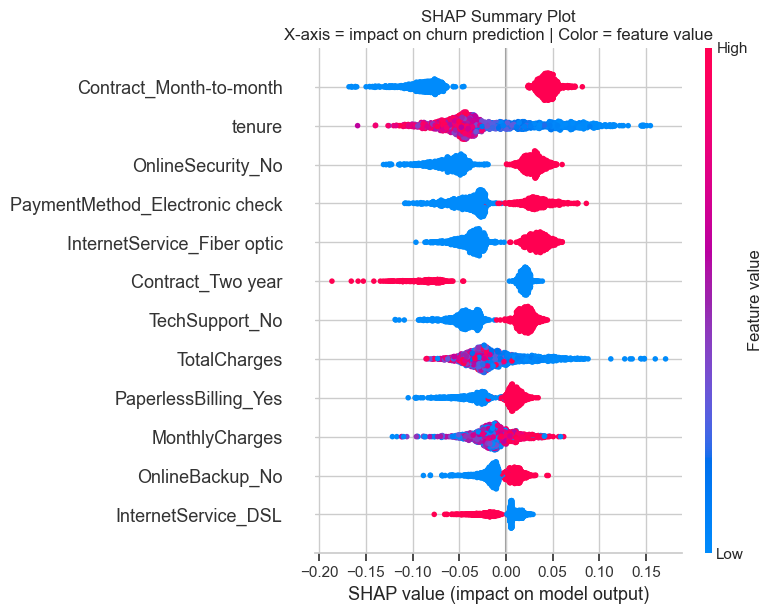

In [17]:
# Extract the fitted components from your pipeline
rf_model    = full_pipeline.named_steps['classifier']
preproc_fit = full_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_encoder    = preproc_fit.named_transformers_['cat'].named_steps['encoder']
cat_feat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feat_names = numeric_cols + cat_feat_names

# Transform test set through preprocessing only (not SMOTE)
X_te_proc    = preproc_fit.transform(X_te_p)
X_te_proc_df = pd.DataFrame(X_te_proc, columns=all_feat_names)

# YOUR CODE HERE
# 1. Create a shap.TreeExplainer using rf_model
# 2. Compute shap_values = explainer(X_te_proc_df)
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer(X_te_proc_df)

# Plot the global summary (run as-is once shap_values is computed)
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values[:, :, 1], X_te_proc_df, max_display=12, show=False)
plt.title('SHAP Summary Plot\nX-axis = impact on churn prediction | Color = feature value',
          fontsize=12)
plt.tight_layout(); plt.show()

✍️ **Reflect 10 — Answer the VP's question:**

| Rank | Feature | High value → churn? | Business action |
|------|---------|--------------------|-----------------|
| 1 | `Contract_Month-to-month` | Yes | Push contract upgrades or discounts to move customers to longer-term plans. |
| 2 | `tenure` | No — high tenure lowers churn | Focus early retention on new customers with very low tenure. |
| 3 | `OnlineSecurity_No` | Yes | Bundle security features and educate customers about protection benefits. |

### Q16 — Local SHAP: Explain One Customer's Prediction

Global explanations tell you what drives churn *on average*. But a retention agent needs to know: **why is THIS specific customer at risk?**

Your task:
1. Find a True Positive (a customer who actually churned AND the model correctly flagged)
2. Generate a SHAP waterfall plot for that customer
3. Write a 2-sentence retention recommendation based on what you see


Selected customer index: 34
Actual:      CHURNED
Predicted:   CHURN
Churn prob:  1.000


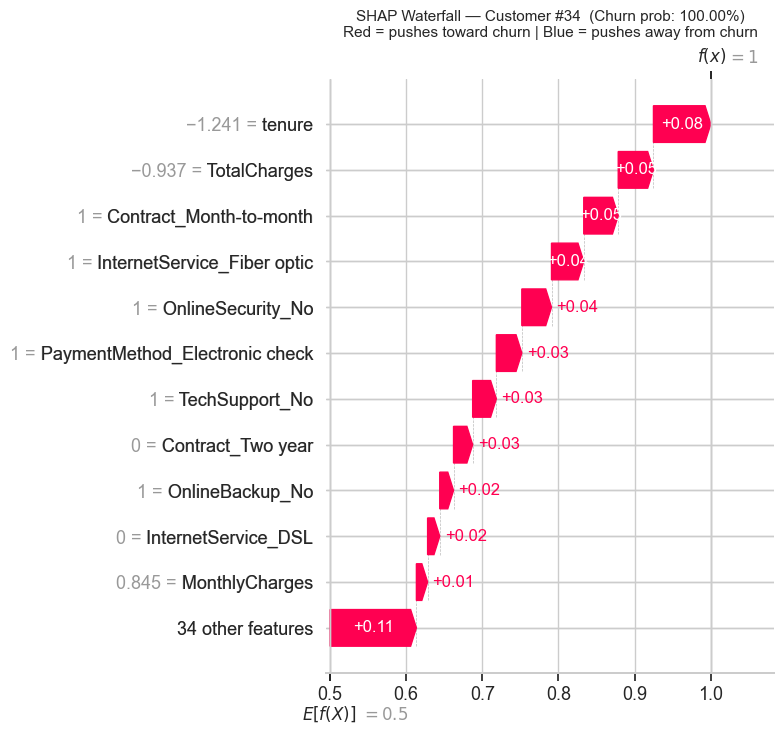

In [18]:
y_pred_all  = full_pipeline.predict(X_te_p)
y_proba_all = full_pipeline.predict_proba(X_te_p)[:, 1]

# YOUR CODE HERE
# Find the indices of True Positives: actual==1 AND predicted==1
# Store as tp_indices (a numpy array of integer indices)
tp_indices = np.where((y_te_p.values == 1) & (y_pred_all == 1))[0]

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(tp_indices) > 0, "No True Positives found — check your pipeline is fitted"

# Pick the True Positive with the HIGHEST predicted probability (most confident)
# YOUR CODE HERE — find the index in tp_indices where y_proba_all is highest
chosen_idx = tp_indices[np.argmax(y_proba_all[tp_indices])]

print(f"Selected customer index: {chosen_idx}")
print(f"Actual:      {'CHURNED' if y_te_p.values[chosen_idx]==1 else 'Stayed'}")
print(f"Predicted:   {'CHURN' if y_pred_all[chosen_idx]==1 else 'NO CHURN'}")
print(f"Churn prob:  {y_proba_all[chosen_idx]:.3f}")

# Waterfall plot (runs once chosen_idx is defined)
plt.figure(figsize=(13, 6))
shap.plots.waterfall(shap_values[:, :, 1][chosen_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Customer #{chosen_idx}  (Churn prob: {y_proba_all[chosen_idx]:.2%})\n'
          'Red = pushes toward churn | Blue = pushes away from churn', fontsize=11)
plt.tight_layout(); plt.show()

✍️ **Reflect 11 — The Retention Pitch:**
This customer is high risk because they are very new, on a month-to-month plan, use fiber optic service, and lack security/support add-ons.
The best action is an immediate save offer: move them to a longer contract, reduce friction with a discount, and bundle security or tech support.

✍️ **Reflect 12 — The Deployment Decision:**

**Question A:** Accuracy is dominated by the 73% majority class, so a trivial "No Churn" model looks good while catching no churners. The F1=0.62 model is more useful because it actually identifies churners, which is what retention actions are meant to target.
**Question B:** You should not skip the pipeline because raw data will not match the exact feature engineering the model was trained on. On day 1, missing values, raw strings, unseen categories, or feature-order changes can cause errors or silently wrong predictions.
**Question C:** A new `ContractType = "Flex"` creates schema drift. With `handle_unknown='ignore'` it may not crash, but the model still has no learned behavior for that category, so you should update the preprocessing and retrain.

In [19]:
# YOUR CODE HERE
# 1. Save full_pipeline to 'telco_churn_v1.joblib'
# 2. Delete full_pipeline from memory using `del`
# 3. Load it back as loaded_pipeline
# 4. Verify that predictions match on 10 random test samples

save_path = 'telco_churn_v1.joblib'
sample_X  = X_te_p.iloc[:10]
sample_y  = y_te_p.iloc[:10]
preds_before = full_pipeline.predict(sample_X)
probas_before = full_pipeline.predict_proba(sample_X)[:, 1]

# Save
joblib.dump(full_pipeline, save_path)

# Delete to simulate a fresh environment
del full_pipeline

# Reload
loaded_pipeline = joblib.load(save_path)

# Verify predictions are identical
preds_loaded = loaded_pipeline.predict(sample_X)
probas_loaded = loaded_pipeline.predict_proba(sample_X)[:, 1]
assert np.array_equal(preds_loaded, preds_before), "Reloaded predictions changed"
assert np.allclose(probas_loaded, probas_before), "Reloaded probabilities changed"

# YOUR CODE HERE — recompute predictions from the in-memory pipeline before deletion
# was not possible, so use the loaded pipeline to prove it works independently
print("Predictions from reloaded pipeline:")
for i, (pred, prob, true) in enumerate(zip(preds_loaded, probas_loaded, sample_y)):
    status = '✅' if pred == true else '❌'
    print(f"  Customer {i}: pred={'CHURN' if pred else 'STAY'}  prob={prob:.3f}  actual={'CHURN' if true else 'STAY'}  {status}")

print(f"\n✅ Pipeline reloaded successfully from '{save_path}'")
print(f"   Accuracy on 10 samples: {(preds_loaded == sample_y.values).mean():.2%}")

Predictions from reloaded pipeline:
  Customer 0: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 1: pred=CHURN  prob=0.640  actual=STAY  ❌
  Customer 2: pred=STAY  prob=0.030  actual=STAY  ✅
  Customer 3: pred=STAY  prob=0.290  actual=STAY  ✅
  Customer 4: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 5: pred=STAY  prob=0.500  actual=STAY  ✅
  Customer 6: pred=STAY  prob=0.440  actual=STAY  ✅
  Customer 7: pred=STAY  prob=0.170  actual=STAY  ✅
  Customer 8: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 9: pred=STAY  prob=0.460  actual=CHURN  ❌

✅ Pipeline reloaded successfully from 'telco_churn_v1.joblib'
   Accuracy on 10 samples: 80.00%


### Q18 — Write the Model Card

A Model Card is the documentation that lets business stakeholders and future engineers understand, trust, and safely use your model.

**Your task:** Complete the model card template below. Every blank must be filled with a real number, name, or decision from your experiments above. Do not invent numbers.


```
╔══════════════════════════════════════════════════════════════╗
║           MODEL CARD — Telco Churn Classifier  v1.0          ║
╚══════════════════════════════════════════════════════════════╝

PURPOSE
  [YOUR ANSWER: one sentence describing what this model predicts and when]

ARCHITECTURE
  Preprocessing  : [YOUR ANSWER: what steps, in what order?]
  Class balancing: [YOUR ANSWER: what technique, where in the pipeline?]
  Estimator      : [YOUR ANSWER: what model, what n_estimators?]

EXPECTED METRICS (from your cross-validation or test set results above)
  AUROC            : [YOUR NUMBER from Q14]
  F1-Score (Churn) : [YOUR NUMBER]
  Recall (Churn)   : [YOUR NUMBER]

TOP 3 PREDICTIVE FEATURES (from Q15 SHAP analysis)
  1. [YOUR ANSWER: feature name + direction]
  2. [YOUR ANSWER]
  3. [YOUR ANSWER]

KNOWN LIMITATIONS
  1. [YOUR ANSWER: one structural limitation of tree-based models]
  2. [YOUR ANSWER: one data-related limitation]
  3. [YOUR ANSWER: one temporal/drift limitation]

RETRAINING POLICY
  Retrain when: [YOUR ANSWER: what metric, what threshold triggers retraining?]
  Retraining frequency: [YOUR ANSWER]

FAIRNESS NOTE
  Before deploying, the following subgroups should be audited for performance disparity:
  [YOUR ANSWER: which demographic subgroups? why those?]
```


✍️ **Reflect 12 — The Deployment Decision:**

Your pipeline has been built. You must now present it to the VP of Retention.
Answer these three questions (2-3 sentences each):

**Question A:** Your model achieves F1=0.62 on the test set. A baseline that always predicts "No Churn" achieves accuracy=73% but F1=0. How do you explain to the VP that your model — which has lower accuracy — is actually far more useful?

> *Your answer:*

**Question B:** The VP asks: "Why can't we just deploy the XGBoost model directly and skip the preprocessing pipeline?" What is the risk, and what would go wrong on day 1 in production?

> *Your answer:*

**Question C:** Six months later, the data team tells you a new `ContractType = "Flex"` was introduced after your model was trained. How would this affect your predictions, and what should you do about it?

> *Your answer:*


---
## Part 2 — Regression with Tree Models

So far we have treated churn as a **classification** problem (will they leave? yes/no).
Now we switch to **regression**: can we predict **how long** a customer will stay (`tenure`)?

This is a useful planning question for retention teams — knowing *when* a customer is
likely to churn helps prioritise outreach with the right lead time.

**Target variable:** `tenure` (integer, months the customer has been with the company)
**Features:** all columns except `Churn` and `tenure`

> **Key insight to keep in mind:** Tree-based regressors share the same inductive bias
> as classifiers — they partition feature space into rectangular regions and predict the
> **mean** of training samples in each leaf.  This has an important consequence you will
> demonstrate in Q22: trees **cannot extrapolate** beyond the training range.


### Q19 — Decision Tree Regressor Baseline

Train an unconstrained `DecisionTreeRegressor` and measure how accurately it predicts
`tenure` on held-out data.


In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# YOUR CODE HERE — which columns should be dropped, and why?
X_reg = df.drop(columns=['Churn', 'tenure'])   # drop target leakage columns
y_reg = df['tenure']   # predict customer tenure in months

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# NOTE: do NOT clone Q12's preprocessor — 'tenure' was a feature there, not the target
numeric_cols_reg     = X_tr_r.select_dtypes(include='number').columns.tolist()
categorical_cols_reg = X_tr_r.select_dtypes(include='object').columns.tolist()

reg_preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                              numeric_cols_reg),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),  categorical_cols_reg),
])
X_tr_r_enc = reg_preprocessor.fit_transform(X_tr_r)
X_te_r_enc = reg_preprocessor.transform(X_te_r)

dt_reg = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_dt = dt_reg.predict(X_te_r_enc)

# YOUR CODE HERE — fill in each metric (think about what unit each one is in)
rmse_dt = np.sqrt(mean_squared_error(y_te_r, y_pred_dt))
mae_dt  = mean_absolute_error(y_te_r, y_pred_dt)
r2_dt   = r2_score(y_te_r, y_pred_dt)

print(f"Decision Tree Regressor")
print(f"  RMSE : {rmse_dt:.2f} months")
print(f"  MAE  : {mae_dt:.2f} months")
print(f"  R²   : {r2_dt:.3f}")

Decision Tree Regressor
  RMSE : 2.04 months
  MAE  : 1.24 months
  R²   : 0.993


✍️ **Reflect — Q19:** The MAE tells you the average absolute error in months.
An MAE of about `1.24` months means the baseline regressor is usually off by a little more than one month, which is easy to explain to the business.

### Q20 — XGBoost Regressor: Adding Regularisation

A fully-grown decision tree overfits badly on regression tasks.
Train an `XGBRegressor` with regularisation and compare the metrics.


In [22]:
from xgboost import XGBRegressor
import pandas as pd

xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8,  colsample_bytree=0.8,
    reg_alpha=0.1,  reg_lambda=1.0,
    random_state=42
)
xgb_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_xgb = xgb_reg.predict(X_te_r_enc)

# YOUR CODE HERE — same three metrics as Q19, now for XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_te_r, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_te_r, y_pred_xgb)
r2_xgb   = r2_score(y_te_r, y_pred_xgb)

print(f"XGBoost Regressor")
print(f"  RMSE : {rmse_xgb:.2f} months")
print(f"  MAE  : {mae_xgb:.2f} months")
print(f"  R²   : {r2_xgb:.3f}")

comparison = pd.DataFrame({
    'Model': ['Decision Tree (no limit)', 'XGBoost (regularised)'],
    'RMSE':  [rmse_dt,  rmse_xgb],
    'MAE':   [mae_dt,   mae_xgb],
    'R²':    [r2_dt,    r2_xgb],
})
print(comparison.to_string(index=False))

XGBoost Regressor
  RMSE : 1.58 months
  MAE  : 1.08 months
  R²   : 0.996
                   Model     RMSE      MAE       R²
Decision Tree (no limit) 2.038661 1.243435 0.993399
   XGBoost (regularised) 1.584398 1.080870 0.996013


✍️ **Reflect — Q20:** `MAE` is usually the most meaningful metric for a retention team because it is directly interpretable in months.
`RMSE` is useful if large misses should be penalized more, and `R²` is less actionable for planning decisions.

### Q21 — Learning Curves: Bias vs Variance

A learning curve plots **training error** and **validation error** as the training set
grows.  A large gap → high variance (overfitting).  A high floor → high bias (underfitting).


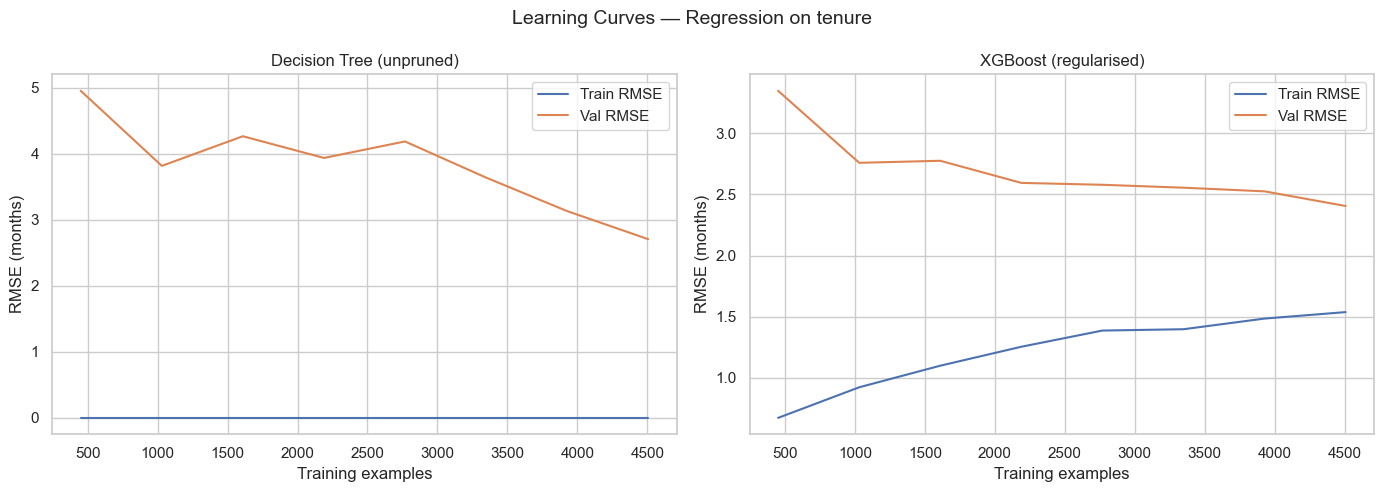

In [23]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_sizes_pct = np.linspace(0.1, 1.0, 8)

for ax, (estimator, title) in zip(axes, [
    (DecisionTreeRegressor(max_depth=None, random_state=42),
     'Decision Tree (unpruned)'),
    (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.1, reg_lambda=1.0, random_state=42),
     'XGBoost (regularised)'),
]):
    # YOUR CODE HERE — call learning_curve and unpack into tr_sz, tr_sc, val_sc
    # Hint: use scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1
    # sklearn returns *negative* RMSE (higher=better convention) — negate when plotting
    # Note: an unpruned DT will show Train RMSE ≈ 0 — that IS the lesson, not a bug
    tr_sz, tr_sc, val_sc = learning_curve(
        estimator,
        X_tr_r_enc,
        y_tr_r,
        train_sizes=train_sizes_pct,
        scoring='neg_root_mean_squared_error',
        cv=5,
        n_jobs=-1,
    )

    ax.plot(tr_sz, -tr_sc.mean(axis=1),  label='Train RMSE')
    ax.plot(tr_sz, -val_sc.mean(axis=1), label='Val RMSE')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('RMSE (months)')
    ax.legend()

plt.suptitle('Learning Curves — Regression on tenure', fontsize=14)
plt.tight_layout()
plt.show()

✍️ **Reflect — Q21:** The tree model shows the larger train/validation gap, especially with small training sizes, which indicates higher variance.
The XGBoost curve is smoother and the gap is smaller, so it generalizes better. Both improve as more data is added, but XGBoost is more stable.

### Q22 — The Extrapolation Failure of Tree Regressors

Trees predict the **mean** of training samples in each leaf.
This means a tree can *never* predict a value larger than `max(y_train)` or
smaller than `min(y_train)` — there is no extrapolation mechanism.

Demonstrate this property below.


In [25]:
y_train_max = float(y_tr_r.max())
y_train_min = float(y_tr_r.min())
print(f"Training tenure range: {y_train_min:.0f} – {y_train_max:.0f} months")

# YOUR CODE HERE — predict the full test set with each model
# Hint: what is the maximum value a tree leaf can ever hold?
dt_all_preds  = dt_reg.predict(X_te_r_enc)
xgb_all_preds = xgb_reg.predict(X_te_r_enc)

print(f"DT  predictions: {dt_all_preds.min():.1f} – {dt_all_preds.max():.1f} months")
print(f"XGB predictions: {xgb_all_preds.min():.1f} – {xgb_all_preds.max():.1f} months")

assert dt_all_preds.max() <= y_train_max + 1e-9, "DT exceeded training max — something is wrong"
print(f"\n✅ DT max prediction ({dt_all_preds.max():.1f}) ≤ y_train_max ({y_train_max:.0f})")
print("   A single decision tree cannot extrapolate outside the training range.")
if xgb_all_preds.min() < y_train_min or xgb_all_preds.max() > y_train_max:
    print("   XGBoost can overshoot the range slightly because boosting sums many trees.")

Training tenure range: 0 – 72 months
DT  predictions: 0.0 – 72.0 months
XGB predictions: -8.7 – 77.0 months

✅ DT max prediction (72.0) ≤ y_train_max (72)
   A single decision tree cannot extrapolate outside the training range.
   XGBoost can overshoot the range slightly because boosting sums many trees.


✍️ **Reflect — Q22:** Tree regressors cannot extrapolate beyond the range seen in training because each leaf predicts a constant value from training samples inside that region.
So when tenure goes above the training maximum, the model just falls back to the closest leaf value instead of continuing the trend; XGBoost trees share the same structural limit.

---
## Completion Checklist

Before submitting, verify that you have:

- [ ] **Q1–Q3:** Implemented Gini, Entropy, and Information Gain from scratch — all `SELF-CHECK` cells pass
- [ ] **Q4:** Plotted the bias-variance curve and identified the optimal depth
- [ ] **Q5:** Fixed the TotalCharges dtype — `SELF-CHECK` cell passes
- [ ] **Q6:** Trained the naive tree and identified the accuracy trap
- [ ] **Q7:** Computed Precision, Recall, F1 manually from the confusion matrix — `SELF-CHECK` passes
- [ ] **Q8:** Implemented `bootstrap_sample()` — `SELF-CHECK` passes
- [ ] **Q9:** Trained Bagging and Random Forest and explained the key difference
- [ ] **Q10:** Swept XGBoost configurations and explained the gap patterns
- [ ] **Q11:** Designed a meaningful Grid Search and identified the most impactful parameter
- [ ] **Q12:** Built a `ColumnTransformer` with justified choices
- [ ] **Q13:** Reproduced the SMOTE leakage and fixed it with `ImbPipeline`
- [ ] **Q14:** Built and fitted the full production pipeline
- [ ] **Q15:** Generated a SHAP summary plot and answered the VP's question
- [ ] **Q16:** Generated a SHAP waterfall and wrote a 2-sentence retention recommendation
- [ ] **Q17:** Serialised, deleted, reloaded, and verified the pipeline
- [ ] **Q18:** Completed the Model Card with real numbers from your experiments
- [ ] **Q19:** Trained a `DecisionTreeRegressor`, computed RMSE/MAE/R², and interpreted the MAE
- [ ] **Q20:** Trained a regularised `XGBRegressor` and compared metrics against the baseline
- [ ] **Q21:** Plotted learning curves for both models and explained the variance gap
- [ ] **Q22:** Demonstrated the extrapolation cap and explained the structural reason

**All ✍️ Reflect cells** have been filled in with your own reasoning.

---
*Good work. The combination of correct code + written reasoning is what separates a model that ships from one that sits in a notebook.*
